# 📊 Projeto de Data Science
### Análise dos Métodos de Pagamento no Brasil

Este projeto analisa a evolução dos principais métodos de pagamento no Brasil ao longo do tempo, identificando mudanças estruturais no comportamento financeiro da população, como o crescimento do PIX e a redução de métodos tradicionais como DOC e cheque.

* Os dados de Cartão de Credito foram extraidos de dados abertos do Banco Central através do link:
https://www.bcb.gov.br/estatisticas/spbadendos?ano=2024
* A planilha do Banco Central do Brasil normalmente vem em formato horizontal, por isso tivemos de tratar a tabela
* Tivemos tambem que excluir as colunas e linhas NaN
* Depois Salvamos e carregamos aqui para fazer a Análise

#### Fonte dos dados:
>https://www.bcb.gov.br/estatisticas/spbadendos?ano=2024
>
>https://www.kaggle.com/datasets/clovisdalmolinvieira/brazilian-payment-methods

#### Instalação e Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o estilo e o tamanho dos gráficos - "darkgrid" → fundo cinza com grid | "white" → fundo branco sem grid
sns.set_style("whitegrid") # Fundo branco (white) | Linhas de grade suaves (grid)
plt.rcParams["figure.figsize"] = (12,6) # rcParams Guarda configurações globais de plotagem | (12,6) → largura 12, altura 6

In [2]:
df = pd.read_csv("dataset.csv")

df_valor = pd.read_csv("valor_cartao_credito.csv")
df_transacoes = pd.read_csv("Numero_Transacoes_Cartao_Credito.csv")

In [3]:
#Backup dos Dados

df_backup = df.copy()
valor_backup = df_valor.copy()
trans_backup = df_transacoes.copy()

#### Limpeza e Padronização das Colunas

In [4]:
# Renomeando as colunas p melhora legibilidade.

df_backup = df_backup.rename(columns={
    "YearMonth":"MesReferencia",
    "quantityPix":"NumeroTransacoesPIX",
    "valuePix":"ValorTotalPIX",
    "quantityTED":"NumeroTransacoesTED",
    "valueTED":"ValorTotalTED",
    "quantityTEC":"NumeroTransacoesTEC",
    "valueTEC":"ValorTotalTEC",
    "quantityBankCheck":"NumeroTransacoesCheque",
    "valueBankCheck":"ValorTotalCheque",
    "quantityBrazilianBoletoPayment":"NumeroTransacoesBoleto",
    "valueBrazilianBoletoPayment":"ValorTotalBoleto",
    "quantityDOC":"NumeroTransacoesDOC",
    "valueDOC":"ValorTotalDOC"
})

In [5]:
df_backup.head()

,MesReferencia,NumeroTransacoesPIX,ValorTotalPIX,NumeroTransacoesTED,ValorTotalTED,NumeroTransacoesTEC,ValorTotalTEC,NumeroTransacoesCheque,ValorTotalCheque,NumeroTransacoesBoleto,ValorTotalBoleto,NumeroTransacoesDOC,ValorTotalDOC
0,202405,5228826.97,2137205.79,69023.11,3482036.97,0.00,0.00,10467.85,40133.55,349180.92,506302.82,0.00,0.00
1,202404,4924681.00,2083746.68,70647.15,3652606.48,0.00,0.00,11179.22,43295.40,361633.28,524619.69,0.00,0.00
2,202403,4903392.34,1936188.21,67565.05,3333054.27,0.00,0.00,10122.46,36644.55,336435.46,469047.59,0.00,0.00
3,202402,4367133.78,1718217.65,65805.87,2981226.45,60.01,109.32,10373.38,37076.26,332269.47,463066.01,61.89,34.21
4,202401,4371541.99,1818473.97,70343.25,3337344.85,387.18,815.94,11919.12,41615.89,363550.32,516702.44,600.76,616.58


In [6]:
# Transformação da Data, e Criando colunas para Ano e Mês

df_backup["MesReferencia"] = pd.to_datetime(df_backup["MesReferencia"], format="%Y%m")

df_backup["Ano"] = df_backup["MesReferencia"].dt.year
df_backup["Mes"] = df_backup["MesReferencia"].dt.month

#### Engenharia de Atributos | Feature Engineering

In [7]:
# Criar novas variáveis úteis. Valor médio de cada transação PIX

df_backup["ValorMedioPIX"] = (df_backup["ValorTotalPIX"] /df_backup["NumeroTransacoesPIX"]).fillna(0)

#### Análise Inicial

In [8]:
df_backup.describe()

,MesReferencia,NumeroTransacoesPIX,ValorTotalPIX,NumeroTransacoesTED,ValorTotalTED,NumeroTransacoesTEC,ValorTotalTEC,NumeroTransacoesCheque,ValorTotalCheque,NumeroTransacoesBoleto,ValorTotalBoleto,NumeroTransacoesDOC,ValorTotalDOC,Ano,Mes,ValorMedioPIX
count,101,1.010000e+02,1.010000e+02,101.000000,1.010000e+02,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,2020-03-01 13:18:24.950494976,9.822789e+05,4.269130e+05,80893.674455,2.341740e+06,728.673366,1494.043069,26852.919802,60465.365050,281402.188218,344113.619901,12522.199208,9539.631485,2019.722772,6.326733,0.211167
min,2016-01-01 00:00:00,0.000000e+00,0.000000e+00,30728.990000,1.101077e+06,0.000000,0.000000,10122.460000,36644.550000,174654.920000,196068.110000,0.000000,0.000000,2016.000000,1.000000,0.000000
25%,2018-02-01 00:00:00,0.000000e+00,0.000000e+00,55697.340000,1.494125e+06,657.190000,1388.890000,16195.580000,49988.270000,216230.670000,253446.630000,5253.950000,4725.760000,2018.000000,3.000000,0.000000
50%,2020-03-01 00:00:00,0.000000e+00,0.000000e+00,74398.370000,2.217642e+06,716.000000,1521.420000,24455.110000,57856.850000,272526.140000,307807.550000,15181.120000,11483.080000,2020.000000,6.000000,0.000000
75%,2022-04-01 00:00:00,1.664792e+06,7.870177e+05,96520.800000,3.159715e+06,801.690000,1649.090000,36378.220000,72834.730000,348653.580000,443844.710000,17385.410000,13355.080000,2022.000000,9.000000,0.429456
max,2024-05-01 00:00:00,5.228827e+06,2.137206e+06,193914.690000,3.810325e+06,1305.510000,2757.910000,50443.050000,85525.270000,380679.530000,524619.690000,29095.160000,20513.660000,2024.000000,12.000000,0.888328
std,NaN,1.506205e+06,6.221059e+05,35956.902905,8.655333e+05,229.288284,449.479457,11964.408858,13305.203291,64675.376751,99628.427137,7118.742203,4964.024293,2.449975,3.481692,0.259016


In [9]:
df_backup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   MesReferencia           101 non-null    datetime64[ns]
 1   NumeroTransacoesPIX     101 non-null    float64       
 2   ValorTotalPIX           101 non-null    float64       
 3   NumeroTransacoesTED     101 non-null    float64       
 4   ValorTotalTED           101 non-null    float64       
 5   NumeroTransacoesTEC     101 non-null    float64       
 6   ValorTotalTEC           101 non-null    float64       
 7   NumeroTransacoesCheque  101 non-null    float64       
 8   ValorTotalCheque        101 non-null    float64       
 9   NumeroTransacoesBoleto  101 non-null    float64       
 10  ValorTotalBoleto        101 non-null    float64       
 11  NumeroTransacoesDOC     101 non-null    float64       
 12  ValorTotalDOC           101 non-null    float64   

In [10]:
# Evolução Anual do PIX

pix_ano = (df_backup.groupby("Ano")["ValorTotalPIX"].sum().reset_index())

In [11]:
pix_ano

,Ano,ValorTotalPIX
0,2016,0.00
1,2017,0.00
2,2018,0.00
3,2019,0.00
4,2020,149894.91
5,2021,5204116.61
6,2022,10890971.89
7,2023,17179392.92
8,2024,9693832.30


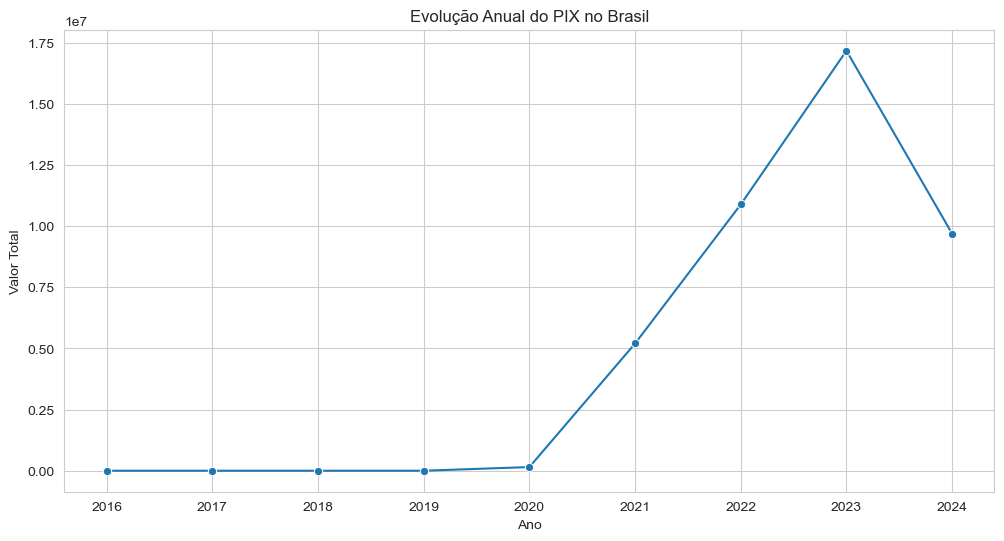

In [12]:
sns.lineplot(data=pix_ano, x="Ano", y="ValorTotalPIX", marker="o")

plt.title("Evolução Anual do PIX no Brasil")
plt.ylabel("Valor Total")
plt.xlabel("Ano")

plt.show()

📌 O PIX apresenta crescimento explosivo após 2020, indicando rápida adoção da tecnologia de pagamentos instantâneos no Brasil.

In [13]:
# Comparação PIX vs Boleto

pix_boleto = df_backup.groupby("Ano")[["ValorTotalPIX","ValorTotalBoleto"]].sum().reset_index()

In [14]:
pix_boleto

,Ano,ValorTotalPIX,ValorTotalBoleto
0,2016,0.00,2825978.70
1,2017,0.00,2909296.13
2,2018,0.00,3126835.74
3,2019,0.00,3510520.27
4,2020,149894.91,3833182.87
5,2021,5204116.61,4808517.51
6,2022,10890971.89,5500145.59
7,2023,17179392.92,5761260.25
8,2024,9693832.30,2479738.55


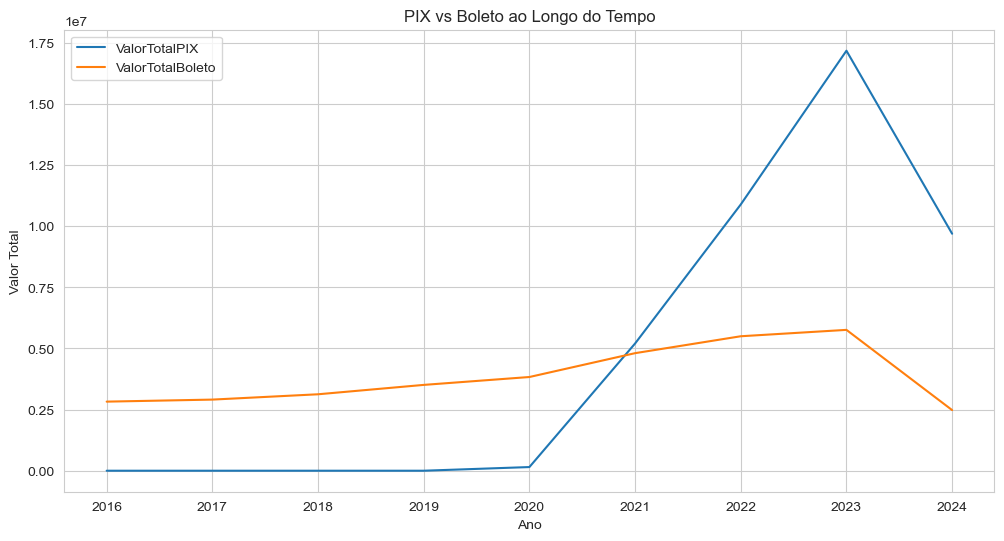

In [15]:
pix_boleto.set_index("Ano").plot()

plt.title("PIX vs Boleto ao Longo do Tempo")
plt.ylabel("Valor Total")
plt.show()

📌 O PIX passou a competir diretamente com o boleto como método de pagamento digital.

In [16]:
# Declínio do DOC

doc_ano = df_backup.groupby("Ano")["ValorTotalDOC"].sum().reset_index()

In [17]:
doc_ano

,Ano,ValorTotalDOC
0,2016,155377.53
1,2017,155262.87
2,2018,161227.51
3,2019,147910.94
4,2020,172371.67
5,2021,81410.28
6,2022,55748.98
7,2023,33542.21
8,2024,650.79


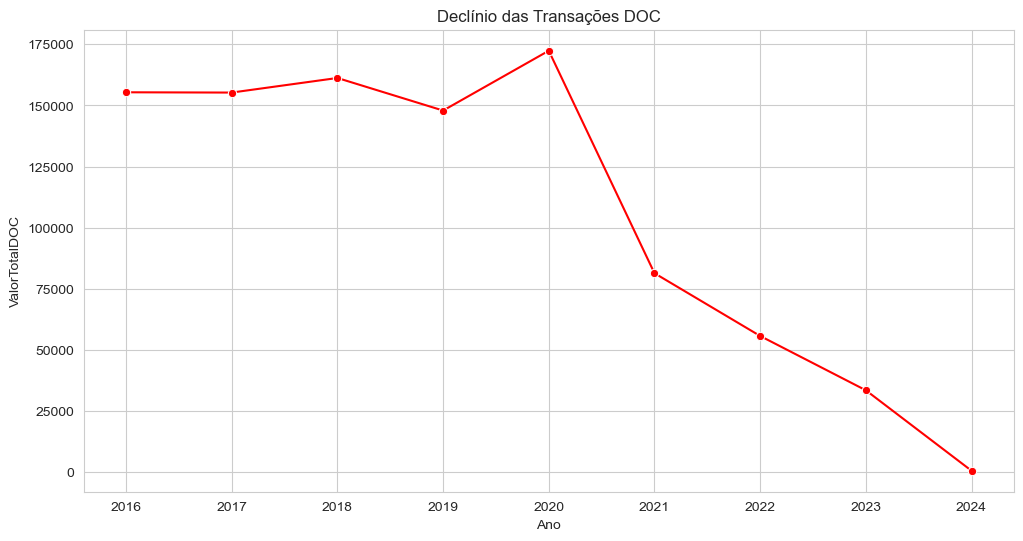

In [18]:
sns.lineplot(data=doc_ano, x="Ano", y="ValorTotalDOC", marker="o", color="red")

plt.title("Declínio das Transações DOC")
plt.show()

📌 O DOC mostra queda contínua, indicando substituição por métodos mais rápidos como PIX e TED.

#### Correlação

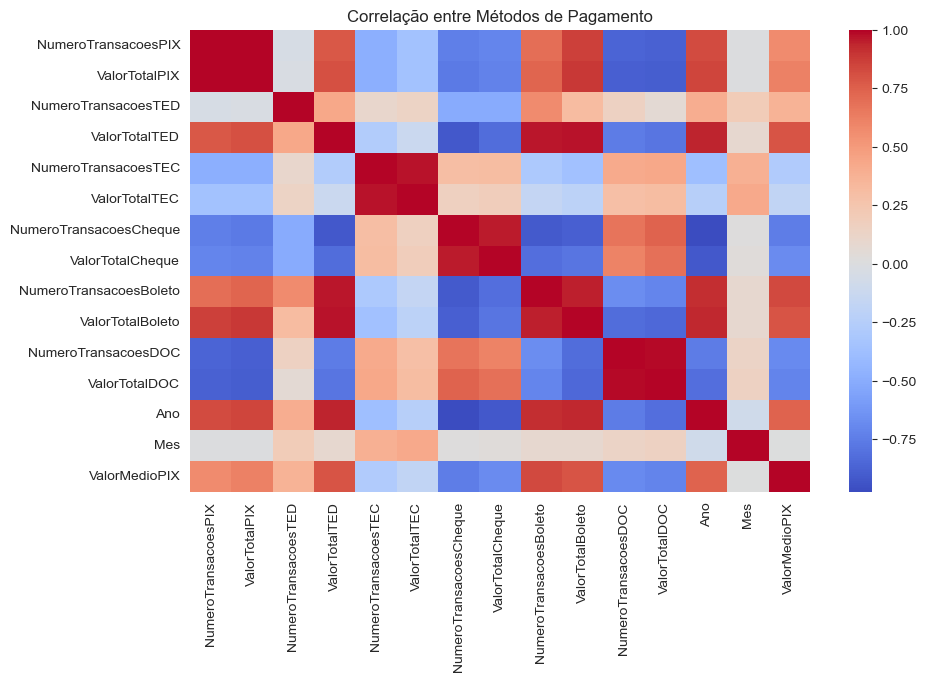

In [19]:
correlacao = df_backup.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(correlacao, cmap="coolwarm", annot=False)

plt.title("Correlação entre Métodos de Pagamento")
plt.show()

📌 Métodos digitais tendem a apresentar correlação positiva, indicando crescimento conjunto.

#### Importação dos Dados de Cartão de Crédito

In [20]:
# Importação dos Dados de Cartão de Crédito | tipo de junção:how="inner" - anos que existem em ambos os DataFrames.

df_cartao = pd.merge(valor_backup, trans_backup, on="Ano")

df_cartao.head()

,Ano,valorcartaocredito,NumeroTransacoesCartaoCredito
0,2011,11640137,440565002
1,2012,11599414,498398296
2,2013,12429519,547092493
3,2014,15965575,625848287
4,2015,14485437,627450033


In [21]:
# Padronização dos Tipos

df_cartao = df_cartao.astype({"valorcartaocredito":float,"NumeroTransacoesCartaoCredito":float})

In [22]:
# Integração com Dataset Principal

df_final = pd.merge(df_backup, df_cartao, on="Ano")

In [23]:
df_final.head()

,MesReferencia,NumeroTransacoesPIX,ValorTotalPIX,NumeroTransacoesTED,ValorTotalTED,NumeroTransacoesTEC,ValorTotalTEC,NumeroTransacoesCheque,ValorTotalCheque,NumeroTransacoesBoleto,ValorTotalBoleto,NumeroTransacoesDOC,ValorTotalDOC,Ano,Mes,ValorMedioPIX,valorcartaocredito,NumeroTransacoesCartaoCredito
0,2024-05-01,5228826.97,2137205.79,69023.11,3482036.97,0.00,0.00,10467.85,40133.55,349180.92,506302.82,0.00,0.00,2024,5,0.408735,10868634.0,1.621664e+09
1,2024-04-01,4924681.00,2083746.68,70647.15,3652606.48,0.00,0.00,11179.22,43295.40,361633.28,524619.69,0.00,0.00,2024,4,0.423123,10868634.0,1.621664e+09
2,2024-03-01,4903392.34,1936188.21,67565.05,3333054.27,0.00,0.00,10122.46,36644.55,336435.46,469047.59,0.00,0.00,2024,3,0.394867,10868634.0,1.621664e+09
3,2024-02-01,4367133.78,1718217.65,65805.87,2981226.45,60.01,109.32,10373.38,37076.26,332269.47,463066.01,61.89,34.21,2024,2,0.393443,10868634.0,1.621664e+09
4,2024-01-01,4371541.99,1818473.97,70343.25,3337344.85,387.18,815.94,11919.12,41615.89,363550.32,516702.44,600.76,616.58,2024,1,0.415980,10868634.0,1.621664e+09


In [24]:
df_final.shape

(101, 18)

#### Participação dos Métodos de Pagamento

In [25]:
# Selecionando último ano.

ultimo_ano = df_final["Ano"].max()

dados_participacao = df_final[df_final["Ano"] == ultimo_ano][[
    "ValorTotalPIX",
    "ValorTotalTED",
    "ValorTotalBoleto",
    "valorcartaocredito"
]].sum()

In [26]:
dados_participacao

ValorTotalPIX          9693832.30
ValorTotalTED         16786269.02
ValorTotalBoleto       2479738.55
valorcartaocredito    54343170.00
dtype: float64

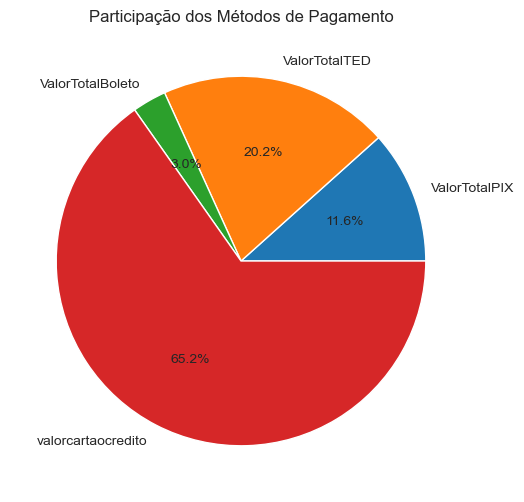

In [27]:
dados_participacao.plot(
    kind="pie",
    autopct="%1.1f%%",
    ylabel=""
)

plt.title("Participação dos Métodos de Pagamento")
plt.show()

#### Dataset Final

In [28]:
# Dataset Final

df_final.to_csv("dataset_Analise_final.csv", index=False)

In [29]:
df_final

,MesReferencia,NumeroTransacoesPIX,ValorTotalPIX,NumeroTransacoesTED,ValorTotalTED,NumeroTransacoesTEC,ValorTotalTEC,NumeroTransacoesCheque,ValorTotalCheque,NumeroTransacoesBoleto,ValorTotalBoleto,NumeroTransacoesDOC,ValorTotalDOC,Ano,Mes,ValorMedioPIX,valorcartaocredito,NumeroTransacoesCartaoCredito
0,2024-05-01,5228826.97,2137205.79,69023.11,3482036.97,0.00,0.00,10467.85,40133.55,349180.92,506302.82,0.00,0.00,2024,5,0.408735,10868634.0,1.621664e+09
1,2024-04-01,4924681.00,2083746.68,70647.15,3652606.48,0.00,0.00,11179.22,43295.40,361633.28,524619.69,0.00,0.00,2024,4,0.423123,10868634.0,1.621664e+09
2,2024-03-01,4903392.34,1936188.21,67565.05,3333054.27,0.00,0.00,10122.46,36644.55,336435.46,469047.59,0.00,0.00,2024,3,0.394867,10868634.0,1.621664e+09
3,2024-02-01,4367133.78,1718217.65,65805.87,2981226.45,60.01,109.32,10373.38,37076.26,332269.47,463066.01,61.89,34.21,2024,2,0.393443,10868634.0,1.621664e+09
4,2024-01-01,4371541.99,1818473.97,70343.25,3337344.85,387.18,815.94,11919.12,41615.89,363550.32,516702.44,600.76,616.58,2024,1,0.415980,10868634.0,1.621664e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,2016-05-01,0.00,0.00,38397.79,1284857.76,658.08,1242.92,49391.10,85525.27,210245.33,243361.74,15222.38,12172.78,2016,5,0.000000,10122151.0,6.558154e+08
97,2016-04-01,0.00,0.00,36144.63,1284108.75,586.71,1029.40,45938.34,79444.79,195789.71,226725.92,14376.42,11632.65,2016,4,0.000000,10122151.0,6.558154e+08
98,2016-03-01,0.00,0.00,37762.98,1387738.67,666.89,1250.64,50443.05,85203.32,207938.76,239690.04,15322.97,12303.86,2016,3,0.000000,10122151.0,6.558154e+08
99,2016-02-01,0.00,0.00,33986.29,1184928.57,576.42,1079.27,46957.82,79927.23,197575.71,225107.82,14455.60,11778.74,2016,2,0.000000,10122151.0,6.558154e+08


## 📊 Principais Insights do Projeto

#### 1️⃣ Crescimento explosivo do PIX

`Após seu lançamento em 2020, o PIX rapidamente se tornou um dos principais meios de pagamento do país.`

#### 2️⃣ Declínio de métodos tradicionais

Métodos como:

        DOC | cheque

`estão praticamente em desuso.`

#### 3️⃣ Mudança estrutural no sistema financeiro

**`O sistema de pagamentos brasileiro passou por uma transformação digital acelerada, com preferência por métodos:`**

        instantâneos, digitais e de baixo custo

# Fim